<a href="https://colab.research.google.com/github/rhonaeloisa/risk.IT.all/blob/main/risk_IT_all_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("risk.IT.model_training").getOrCreate()

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**LOAD THE PARQUET FILE**

In [ ]:
path = "/content/drive/MyDrive/bigdata/df_cleaned.parquet"

df_cleaned = spark.read.parquet(path)

df_cleaned.show(5)

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|           2016|
|    321214|trusses wood roof...|          105522.0|                    1|             2|   2|                 1|           2016|
|    541511|applications soft...|          192000.0|                    2|             0| 

# **FEATURE ENGINEERING**

**INDEXING**

In [ ]:
from pyspark.sql import functions as F

df_risk_level = df_cleaned.withColumn(
    "risk_level",
    F.when(F.col("total_injuries") <= 5, "Low")
     .when(F.col("total_injuries") <= 15, "Medium")
     .otherwise("High")
)

df_risk_level.select("total_injuries", "risk_level").show()

+--------------+----------+
|total_injuries|risk_level|
+--------------+----------+
|             8|    Medium|
|             1|       Low|
|             0|       Low|
|             2|       Low|
|             0|       Low|
|             2|       Low|
|            15|    Medium|
|            35|      High|
|             1|       Low|
|             1|       Low|
|             0|       Low|
|             1|       Low|
|             4|       Low|
|             6|    Medium|
|             7|    Medium|
|             7|    Medium|
|            12|    Medium|
|             6|    Medium|
|             3|       Low|
|             2|       Low|
+--------------+----------+
only showing top 20 rows


In [ ]:
df_risk_level.show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|risk_level|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|    Medium|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|       Low|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|           2016|       Low|
|    321214|trusses wood roof...|          105522.0|                    1|             2|   2|                 1|           2016|       Low|
|    541511|a

In [ ]:
#encode risk level
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(
    inputCol="risk_level",
    outputCol="risk_level_index"
)

df_riskLevel_index = indexer.fit(df_risk_level).transform(df_risk_level)

In [ ]:
df_riskLevel_index.select("risk_level", "risk_level_index").show(50, truncate=False)

+----------+----------------+
|risk_level|risk_level_index|
+----------+----------------+
|Medium    |1.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Medium    |1.0             |
|High      |2.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Low       |0.0             |
|Low       |0.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low      

In [ ]:
df_riskLevel_index.show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|risk_level|risk_level_index|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|    Medium|             1.0|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|       Low|             0.0|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|           2016|       Low|             0.0|
|    321214|trusses wood roof...|          105522.0|

In [ ]:
# SKEWNESS BALANCING MATH: Count class distribution
total_records = df_riskLevel_index.count()
class_distribution = df_riskLevel_index.groupBy("risk_level_index").count().collect()

category_counts = {row["risk_level_index"]: row["count"] for row in class_distribution}
total_classes = len(category_counts)

# Balancing Formula: Total / (Classes * Class Count)
class_weights = {risk_idx: total_records / (total_classes * count) for risk_idx, count in category_counts.items()}

kv_pairs = []
for key, val in class_weights.items():
    kv_pairs.append(F.lit(key))
    kv_pairs.append(F.lit(val))

weight_mapping = F.create_map(kv_pairs)
df_final_preprocessed = df_riskLevel_index.withColumn("weight_col", weight_mapping[F.col("risk_level_index")])

print("Calculated Class Weights:", class_weights)

Calculated Class Weights: {0.0: 0.4109782457622732, 1.0: 2.401723338461586, 2.0: 6.648339644935205}


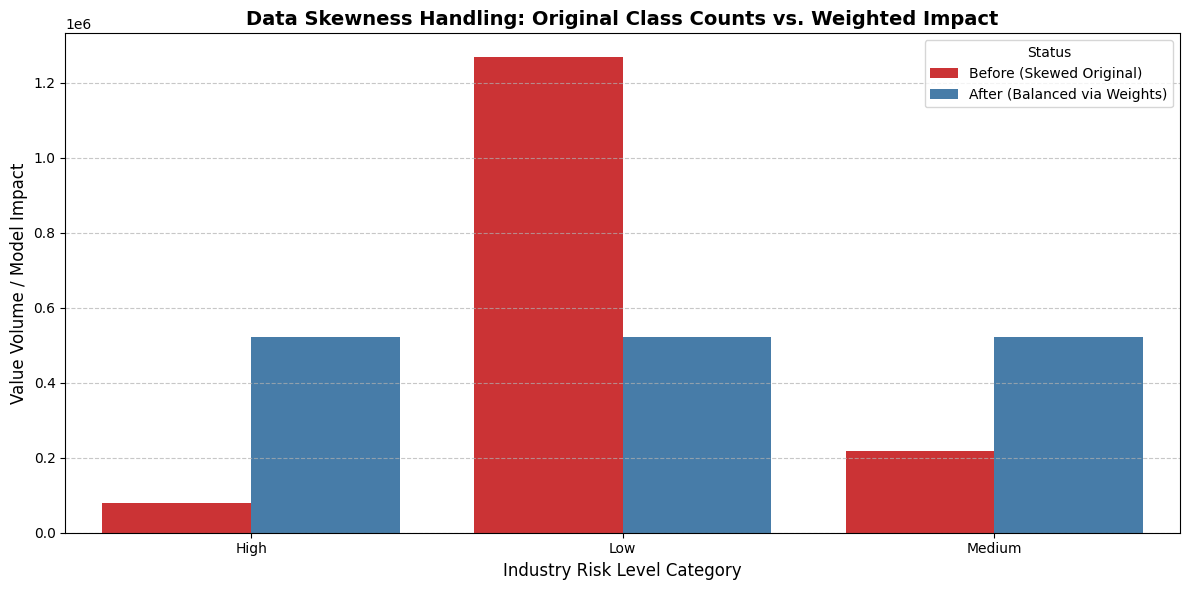

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Get distribution from preprocessed DF
distribution_data = df_final_preprocessed.groupBy("risk_level", "weight_col").count().toPandas()

# 2. Calcultae 'Weighted Impact' (Count * Weight)
distribution_data['Weighted Impact'] = distribution_data['count'] * distribution_data['weight_col']

plot_data = pd.melt(
    distribution_data,
    id_vars=['risk_level'],
    value_vars=['count', 'Weighted Impact'],
    var_name='Status',
    value_name='Volume'
)
plot_data['Status'] = plot_data['Status'].replace({'count': 'Before (Skewed Original)', 'Weighted Impact': 'After (Balanced via Weights)'})

# Show Side-by-SideComparison of Skewness
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="risk_level", y="Volume", hue="Status", palette="Set1")

plt.title("Data Skewness Handling: Original Class Counts vs. Weighted Impact", fontsize=14, fontweight='bold')
plt.xlabel("Industry Risk Level Category", fontsize=12)
plt.ylabel("Value Volume / Model Impact", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df_final_preprocessed.show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+------------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|risk_level|risk_level_index|        weight_col|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+------------------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|    Medium|             1.0| 2.401723338461586|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|       Low|             0.0|0.4109782457622732|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|  

**FINAL FEATURES**

In [ ]:
#final features for regression
df_reg = df_final_preprocessed.select(
    "naics_code",
    "total_hours_worked",
    "no_injuries_illnesses",
    "size",
    "establishment_type",
    "year_filing_for",
    "total_injuries"
)

In [ ]:
from pyspark.ml.feature import VectorAssembler

# assembler for regression model
assembler_reg = VectorAssembler(
    inputCols=[
        "naics_code",
        "total_hours_worked",
        "no_injuries_illnesses",
        "size",
        "establishment_type",
        "year_filing_for"
    ],
    outputCol="features"
)

df_regression_vector = assembler_reg.transform(df_reg)

In [ ]:
#final features for classification
df_class = df_final_preprocessed.select(
    "naics_code",
    "total_hours_worked",
    "no_injuries_illnesses",
    "size",
    "establishment_type",
    "year_filing_for",
    "weight_col",
    "risk_level_index"
)

In [ ]:
# assembler for classification model
assembler_class = VectorAssembler(
    inputCols=[
        "naics_code",
        "total_hours_worked",
        "size",
        "establishment_type",
        "year_filing_for"
    ],
    outputCol="features"
)

df_classification_vector = assembler_class.transform(df_class)

In [ ]:
# split regression dataset
train_reg, test_reg = df_regression_vector.randomSplit([0.8, 0.2], seed=42)

# split classification dataset
train_class, test_class = df_classification_vector.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# regression
train_reg.write.mode("overwrite").parquet("/content/train_regression.parquet")
test_reg.write.mode("overwrite").parquet("/content/test_regression.parquet")

# classification
train_class.write.mode("overwrite").parquet("/content/train_classification.parquet")
test_class.write.mode("overwrite").parquet("/content/test_classification.parquet")

**VISUALIZATION (TO REMOVE)**

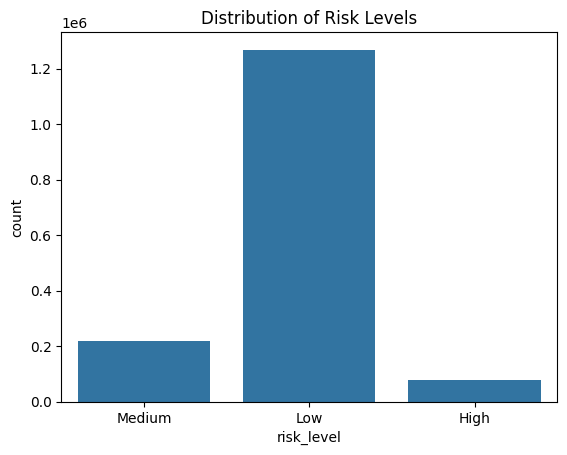

In [ ]:
pdf = df_final_preprocessed.select("risk_level").toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="risk_level", data=pdf)

plt.title("Distribution of Risk Levels")
plt.show()

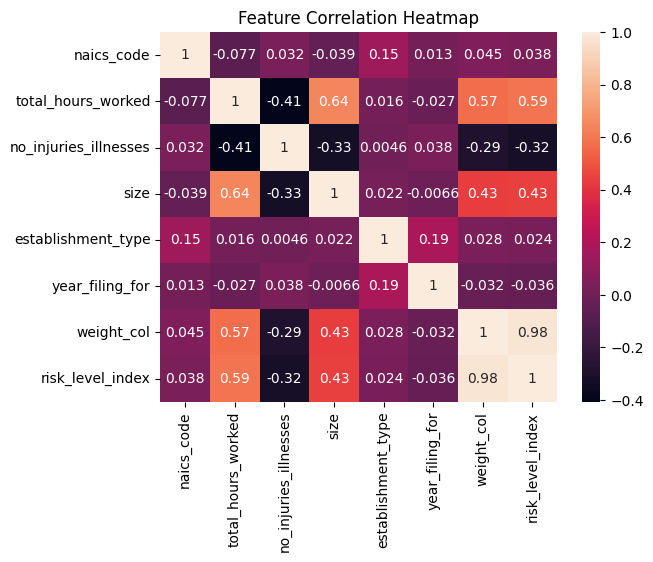

In [ ]:
pdf = df_class.toPandas()

numeric_pdf = pdf.select_dtypes(include=['number'])

sns.heatmap(numeric_pdf.corr(), annot=True)

plt.title("Feature Correlation Heatmap")
plt.show()

# **CLASSIFIER MODEL IMPLEMENTATION**

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

# Classifier instantiation
rf = RandomForestClassifier(
    labelCol="risk_level_index",
    featuresCol="features",
    numTrees=20,
    maxDepth=5
)

# Train the model using the train_class
rf_model = rf.fit(train_class)

# Make predictions on the test_class
predictions = rf_model.transform(test_class)

# Show how the model performs on Low Risk cases
predictions.filter(predictions.risk_level_index == 0.0) \
           .select("risk_level_index", "prediction", "probability") \
           .show(10)

# Show how the model performs on Medium Risk cases
predictions.filter(predictions.risk_level_index == 1.0) \
           .select("risk_level_index", "prediction", "probability") \
           .show(10)

# Show how the model performs on High Risk cases
predictions.filter(predictions.risk_level_index == 2.0) \
           .select("risk_level_index", "prediction", "probability") \
           .show(10)

+----------------+----------+--------------------+
|risk_level_index|prediction|         probability|
+----------------+----------+--------------------+
|             0.0|       0.0|[0.93331886476943...|
|             0.0|       0.0|[0.93331886476943...|
|             0.0|       0.0|[0.92622198052950...|
|             0.0|       0.0|[0.92622198052950...|
|             0.0|       0.0|[0.92622198052950...|
|             0.0|       0.0|[0.90377369548370...|
|             0.0|       0.0|[0.92622198052950...|
|             0.0|       0.0|[0.64362861914581...|
|             0.0|       0.0|[0.92622198052950...|
|             0.0|       0.0|[0.92622198052950...|
+----------------+----------+--------------------+
only showing top 10 rows
+----------------+----------+--------------------+
|risk_level_index|prediction|         probability|
+----------------+----------+--------------------+
|             1.0|       0.0|[0.92622198052950...|
|             1.0|       0.0|[0.71242628767715...|
|     

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Setup the evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="risk_level_index",
    predictionCol="prediction"
)

# Calculate Accuracy
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
# Calculate F1-Score
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print(f"--- BASELINE CLASSIFICATION METRICS ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

--- BASELINE CLASSIFICATION METRICS ---
Accuracy: 0.8281
F1-Score: 0.7981


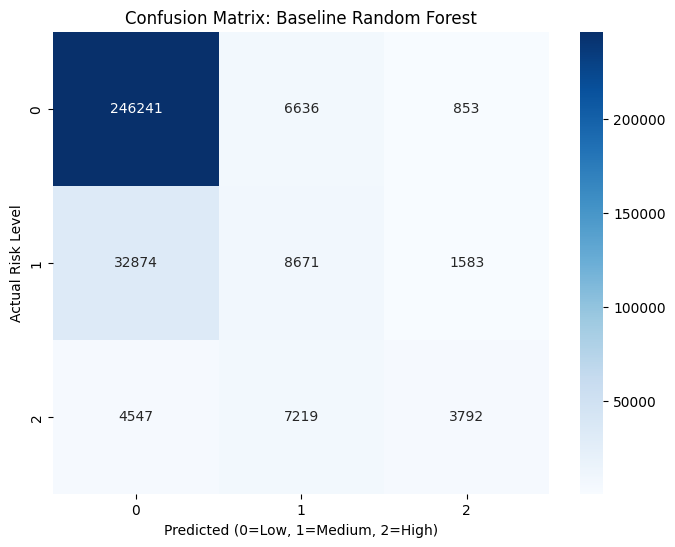

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to Pandas for plotting
y_true = predictions.select("risk_level_index").toPandas()
y_pred = predictions.select("prediction").toPandas()

# Create Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Baseline Random Forest')
plt.xlabel('Predicted (0=Low, 1=Medium, 2=High)')
plt.ylabel('Actual Risk Level')
plt.show()

/tmp/ipykernel_11712/2974636527.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_class_df, palette='magma')


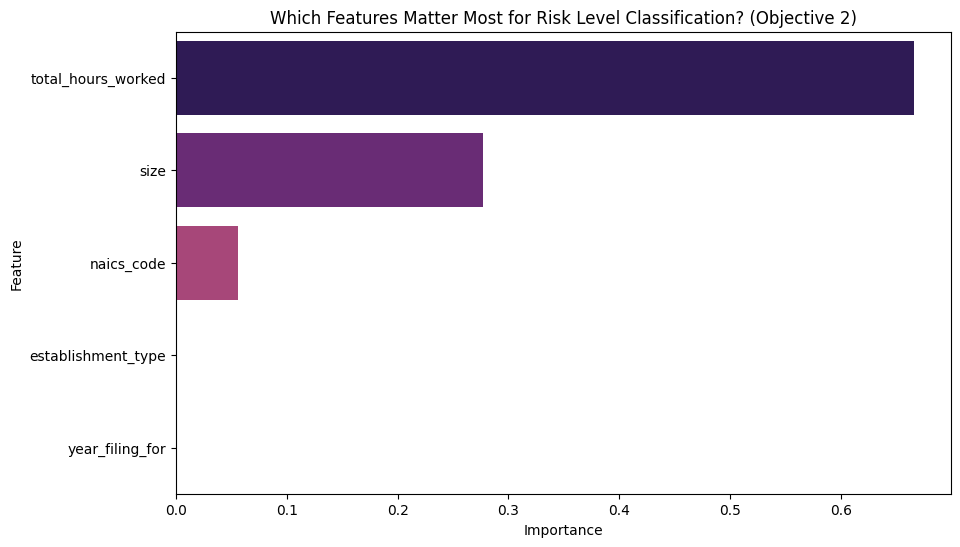

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances_class = rf_model.featureImportances
feature_list_class = ["naics_code", "total_hours_worked", "size", "establishment_type", "year_filing_for"]

feat_imp_class_df = pd.DataFrame({
    'Feature': feature_list_class,
    'Importance': importances_class.toArray()
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_class_df, palette='magma')
plt.title('Which Features Matter Most for Risk Level Classification? (Objective 2)')
plt.show()

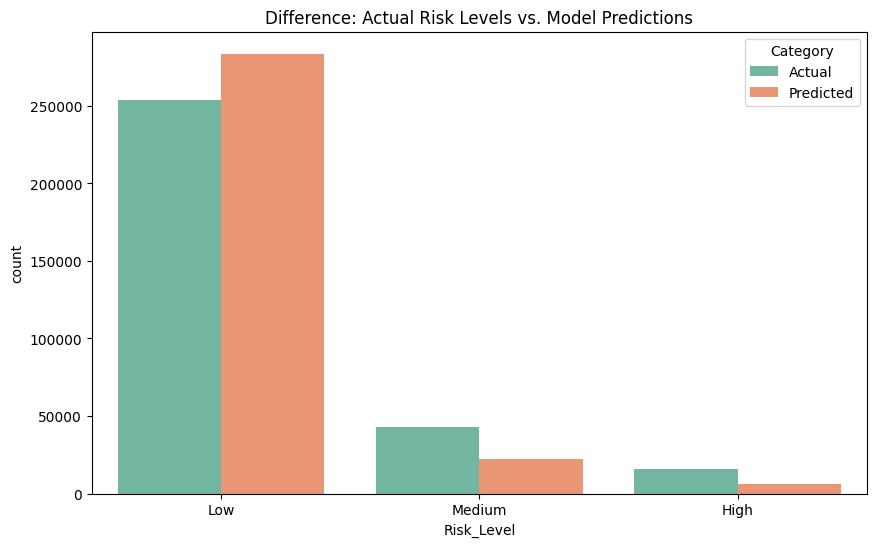

In [ ]:
# Kunin ang counts ng actual vs predicted
comparison_df = predictions.select("risk_level_index", "prediction").toPandas()

# I-reshape ang data para sa plotting
plot_data = pd.melt(comparison_df, value_vars=['risk_level_index', 'prediction'],
                    var_name='Type', value_name='Risk_Level')

plt.figure(figsize=(10, 6))
sns.countplot(x='Risk_Level', hue='Type', data=plot_data, palette='Set2')
plt.title('Difference: Actual Risk Levels vs. Model Predictions')
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'])
plt.legend(title='Category', labels=['Actual', 'Predicted'])
plt.show()

In [ ]:
# =========================================================================
# **CORRECTED CLASSIFIER MODEL IMPLEMENTATION (WITH & WITHOUT WEIGHTS)**
# =========================================================================
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. RUN 1: UNWEIGHTED BASELINE MODEL (What you ran originally)
print("Training Unweighted Baseline Classifier...")
rf_unweighted = RandomForestClassifier(
    labelCol="risk_level_index",
    featuresCol="features",
    numTrees=20,
    maxDepth=5,
    seed=42
)
rf_model_unweighted = rf_unweighted.fit(train_class)
rf_predictions = rf_model_unweighted.transform(test_class) # Saved for comparison script


# 2. RUN 2: WEIGHTED BALANCED MODEL (Fixing the missing parameter!)
print("Training Weighted Balanced Classifier...")
rf_weighted = RandomForestClassifier(
    labelCol="risk_level_index",
    featuresCol="features",
    weightCol="weight_col",    # <--- THIS IS THE MAGIC LINE THAT WAS MISSING!
    numTrees=20,
    maxDepth=5,
    seed=42
)
rf_model_weighted = rf_weighted.fit(train_class)
weighted_rf_predictions = rf_model_weighted.transform(test_class) # Saved for comparison script


# =========================================================================
# **EVALUATION & SIDE-BY-SIDE CONFUSION MATRIX COMPARISON**
# =========================================================================
print("\nExtracting prediction arrays for isolated weight analysis...")
y_true_no_weight = rf_predictions.select("risk_level_index").toPandas()
y_pred_no_weight = rf_predictions.select("prediction").toPandas()

y_true_with_weight = weighted_rf_predictions.select("risk_level_index").toPandas()
y_pred_with_weight = weighted_rf_predictions.select("prediction").toPandas()

cm_no_weight = confusion_matrix(y_true_no_weight, y_pred_no_weight)
cm_with_weight = confusion_matrix(y_true_with_weight, y_pred_with_weight)

class_labels = ['Low Risk', 'Medium Risk', 'High Risk']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Diagram: No Weights (Your original run output)
sns.heatmap(cm_no_weight, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels, cbar=False)
axes[0].set_title('1. BASELINE RUN: No Class Weights\n(AI heavily biases toward the majority)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Risk Level')
axes[0].set_ylabel('Actual Risk Level')

# Right Diagram: With Weights Only (Your actual balanced output!)
sns.heatmap(cm_with_weight, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=class_labels, yticklabels=class_labels, cbar=False)
axes[1].set_title('2. WEIGHTED RUN: Dynamic Class Weights Active\n(AI forced to pay attention to minority classes)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Risk Level')
axes[1].set_ylabel('Actual Risk Level')

plt.tight_layout()
plt.show()

Training Unweighted Baseline Classifier...
Training Weighted Balanced Classifier...

Extracting prediction arrays for isolated weight analysis...


KeyboardInterrupt: 

**REGRESSION**

In [ ]:
#regression
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# linear regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol="total_injuries"
)

# train the model
lr_model = lr.fit(train_reg)

# create predictions
predictions = lr_model.transform(test_reg)

# sample predictions
predictions.select(
    "total_injuries",
    "prediction"
).show(10)

# regression metrics
evaluator = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction"
)

# RMSE
rmse = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "rmse"}
)

# MAE
mae = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "mae"}
)

# R2
r2 = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "r2"}
)

print("--- BASELINE REGRESSION METRICS ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

# get the predicted at actual values
plot_df = predictions.select(
    "total_injuries",
    "prediction"
).toPandas()

# scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="total_injuries",
    y="prediction",
    data=plot_df
)

plt.title("Predicted vs Actual Total Injuries")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")

plt.show()

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

RANDOM FOREST REGRESSION

In [ ]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest Regressor model
rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    numTrees=10, # used 10 trees as in the classifier example
    seed=42
)

# train the model
rf_regressor_model = rf_regressor.fit(train_reg)

# create predictions
predictions_rf = rf_regressor_model.transform(test_reg)

# sample predictions
predictions_rf.select(
    "total_injuries",
    "prediction"
).show(10)

# regression metrics
evaluator_rf = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction"
)

# RMSE
rmse_rf = evaluator_rf.evaluate(
    predictions_rf,
    {evaluator_rf.metricName: "rmse"}
)

# MAE
mae_rf = evaluator_rf.evaluate(
    predictions_rf,
    {evaluator_rf.metricName: "mae"}
)

# R2
r2_rf = evaluator_rf.evaluate(
    predictions_rf,
    {evaluator_rf.metricName: "r2"}
)

print("--- RANDOM FOREST REGRESSION METRICS ---")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE : {mae_rf:.4f}")
print(f"R2  : {r2_rf:.4f}")

# get the predicted and actual values
plot_df_rf = predictions_rf.select(
    "total_injuries",
    "prediction"
).toPandas()

# scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="total_injuries",
    y="prediction",
    data=plot_df_rf
)

plt.title("Predicted vs Actual Total Injuries (Random Forest)")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")

plt.show()

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

tuned_rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)

tuning_evaluator = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="rmse"
)

paramGrid = (
    ParamGridBuilder()
    .addGrid(tuned_rf_regressor.numTrees, [50, 100])
    .addGrid(tuned_rf_regressor.maxDepth, [5, 8])
    .addGrid(tuned_rf_regressor.minInstancesPerNode, [1, 5])
    .build()
)

print(f"Number of parameter combinations to test: {len(paramGrid)}")

tvs = TrainValidationSplit(
    estimator=tuned_rf_regressor,
    estimatorParamMaps=paramGrid,
    evaluator=tuning_evaluator,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

tvs_model = tvs.fit(train_reg)

print("Tuning complete.")

tuned_rf_model = tvs_model.bestModel
tuned_predictions_rf = tuned_rf_model.transform(test_reg)

tuned_rmse = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="rmse"
).evaluate(tuned_predictions_rf)

tuned_mae = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="mae"
).evaluate(tuned_predictions_rf)

tuned_r2 = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="r2"
).evaluate(tuned_predictions_rf)

print("--- TUNED RANDOM FOREST METRICS ---")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"MAE : {tuned_mae:.4f}")
print(f"R2  : {tuned_r2:.4f}")

print("--- BEST RANDOM FOREST PARAMETERS ---")
print("Best numTrees:", tuned_rf_model.getNumTrees)
print("Best maxDepth:", tuned_rf_model.getMaxDepth())
print("Best minInstancesPerNode:", tuned_rf_model.getMinInstancesPerNode())


print("--- BASE VS TUNED COMPARISON ---")
print(f"Base RMSE : {rmse_rf:.4f}")
print(f"Tuned RMSE: {tuned_rmse:.4f}")

print(f"Base MAE  : {mae_rf:.4f}")
print(f"Tuned MAE : {tuned_mae:.4f}")

print(f"Base R2   : {r2_rf:.4f}")
print(f"Tuned R2  : {tuned_r2:.4f}")


Number of parameter combinations to test: 8
Tuning complete.
--- TUNED RANDOM FOREST METRICS ---
RMSE: 13.0090
MAE : 3.0884
R2  : 0.2597
--- BEST RANDOM FOREST PARAMETERS ---
Best numTrees: 100
Best maxDepth: 8
Best minInstancesPerNode: 1
--- BASE VS TUNED COMPARISON ---
Base RMSE : 13.1989
Tuned RMSE: 13.0090
Base MAE  : 3.2113
Tuned MAE : 3.0884
Base R2   : 0.2379
Tuned R2  : 0.2597


## **Objective 1: Regression Model**

Objective: predict the expected number of workplace incidents using historical data.

Target: `total_injuries`


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, FeatureHasher
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor, GeneralizedLinearRegression
from pyspark.ml.classification import RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Backward compatibility: add new predictor columns if an older parquet file is loaded.
if "industry_description" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("industry_description", F.lit("unknown"))
if "state" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("state", F.lit("unknown"))
if "annual_average_employees" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("annual_average_employees", F.lit(0.0))

# Feature engineering for Objective 1 regression.
# total_injuries is the original count label. log_total_injuries is added for skewed-count modeling.
# Poisson regression requires a non-negative label, so invalid negative injury counts are removed.
df_reg = df_cleaned.fillna({
    "naics_code": 0,
    "industry_description": "unknown",
    "state": "unknown",
    "annual_average_employees": 0.0,
    "total_hours_worked": 0.0,
    "no_injuries_illnesses": 0,
    "size": 0,
    "establishment_type": 0,
    "year_filing_for": 0,
    "total_injuries": 0
}).filter(
    F.col("total_injuries") >= 0
).withColumn(
    "injury_illness_rate_per_200k",
    F.when(
        F.col("total_hours_worked") > 0,
        (F.col("no_injuries_illnesses") / F.col("total_hours_worked")) * F.lit(200000.0)
    ).otherwise(F.lit(0.0))
).withColumn(
    "log_total_hours_worked",
    F.log(F.col("total_hours_worked") + F.lit(1.0))
).withColumn(
    "log_annual_average_employees",
    F.log(F.col("annual_average_employees") + F.lit(1.0))
).withColumn(
    "log_total_injuries",
    F.log(F.col("total_injuries") + F.lit(1.0))
).fillna({
    "log_total_hours_worked": 0.0,
    "log_annual_average_employees": 0.0,
    "injury_illness_rate_per_200k": 0.0,
    "log_total_injuries": 0.0
})

regression_feature_cols = [
    "naics_code",
    "industry_description",
    "state",
    "annual_average_employees",
    "log_annual_average_employees",
    "total_hours_worked",
    "log_total_hours_worked",
    "no_injuries_illnesses",
    "injury_illness_rate_per_200k",
    "size",
    "establishment_type",
    "year_filing_for"
]

invalid_negative_injury_rows = df_cleaned.filter(F.col("total_injuries") < 0).count()
print("Rows removed because total_injuries was negative:", invalid_negative_injury_rows)
print("Regression inputs used:")
for feature in regression_feature_cols:
    print("-", feature)

train_reg, test_reg = df_reg.select(regression_feature_cols + ["total_injuries", "log_total_injuries"]).randomSplit([0.8, 0.2], seed=42)
train_reg = train_reg.cache()
test_reg = test_reg.cache()
print("Training rows:", train_reg.count())
print("Testing rows:", test_reg.count())

# Keep the original train/test parquet workflow.
train_reg.write.mode("overwrite").parquet("/content/train_regression.parquet")
test_reg.write.mode("overwrite").parquet("/content/test_regression.parquet")

# FeatureHasher allows numeric + categorical predictors inside the PySpark Pipeline.
# 256 features keeps memory lower than a very wide hashed vector in Colab.
assembler_reg = FeatureHasher(inputCols=regression_feature_cols, outputCol="features", numFeatures=256)


Rows removed because total_injuries was negative: 2
Regression inputs used:
- naics_code
- industry_description
- state
- annual_average_employees
- log_annual_average_employees
- total_hours_worked
- log_total_hours_worked
- no_injuries_illnesses
- injury_illness_rate_per_200k
- size
- establishment_type
- year_filing_for
Training rows: 1273959
Testing rows: 317868


In [ ]:
# Baseline regression models using PySpark Pipeline
lr = LinearRegression(featuresCol="features", labelCol="total_injuries")
rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    numTrees=50,
    maxDepth=8,
    seed=42
)
gbt_regressor = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
log_gbt_regressor_baseline = GBTRegressor(
    featuresCol="features",
    labelCol="log_total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
poisson_glr_baseline = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="total_injuries",
    family="poisson",
    link="log",
    maxIter=10,
    regParam=0.0
)

lr_pipeline = Pipeline(stages=[assembler_reg, lr])
rf_pipeline = Pipeline(stages=[assembler_reg, rf_regressor])
gbt_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor])
log_gbt_pipeline_baseline = Pipeline(stages=[assembler_reg, log_gbt_regressor_baseline])
poisson_pipeline_baseline = Pipeline(stages=[assembler_reg, poisson_glr_baseline])

lr_model = lr_pipeline.fit(train_reg)
lr_predictions = lr_model.transform(test_reg)

rf_model = rf_pipeline.fit(train_reg)
rf_predictions = rf_model.transform(test_reg)

gbt_model = gbt_pipeline.fit(train_reg)
gbt_predictions = gbt_model.transform(test_reg)

log_gbt_model_baseline = log_gbt_pipeline_baseline.fit(train_reg)
log_gbt_baseline_raw = log_gbt_model_baseline.transform(test_reg)
log_gbt_baseline_predictions = log_gbt_baseline_raw.withColumn(
    "prediction_count",
    F.greatest(F.exp(F.col("prediction")) - F.lit(1.0), F.lit(0.0))
)

poisson_model_baseline = poisson_pipeline_baseline.fit(train_reg)
poisson_baseline_predictions = poisson_model_baseline.transform(test_reg)

reg_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")
reg_mae = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="mae")
reg_r2 = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")

reg_rmse_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="rmse")
reg_mae_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="mae")
reg_r2_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="r2")

log_rmse = RegressionEvaluator(labelCol="log_total_injuries", predictionCol="prediction", metricName="rmse")

def get_regression_metrics(model_name, training_stage, predictions_df, prediction_col="prediction"):
    if prediction_col == "prediction_count":
        return {
            "Model": model_name,
            "Training Stage": training_stage,
            "RMSE": reg_rmse_count.evaluate(predictions_df),
            "MAE": reg_mae_count.evaluate(predictions_df),
            "R2": reg_r2_count.evaluate(predictions_df)
        }
    return {
        "Model": model_name,
        "Training Stage": training_stage,
        "RMSE": reg_rmse.evaluate(predictions_df),
        "MAE": reg_mae.evaluate(predictions_df),
        "R2": reg_r2.evaluate(predictions_df)
    }

baseline_regression_results = pd.DataFrame([
    get_regression_metrics("Linear Regression", "Baseline", lr_predictions),
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("Log-Target GBT", "Baseline", log_gbt_baseline_predictions, prediction_col="prediction_count"),
    get_regression_metrics("Poisson GLR", "Baseline", poisson_baseline_predictions)
])

baseline_regression_results


,Model,Training Stage,RMSE,MAE,R2
0,Linear Regression,Baseline,15.173919,4.770310,0.194298
1,Random Forest,Baseline,12.372933,2.725875,0.464297
2,GBT Regressor,Baseline,12.267448,2.758179,0.473392
3,Log-Target GBT,Baseline,13.960499,2.554030,0.318006
4,Poisson GLR,Baseline,13.823404,2.719022,0.331335


In [ ]:
# Fine-tune Random Forest and standard GBT using PySpark Pipeline.
rf_regressor_tuned = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
rf_tuned_pipeline = Pipeline(stages=[assembler_reg, rf_regressor_tuned])

# Smaller grid to prevent SparkContext shutdown in Colab.
paramGrid_rf_reg = (
    ParamGridBuilder()
    .addGrid(rf_regressor_tuned.numTrees, [50, 100])
    .addGrid(rf_regressor_tuned.maxDepth, [6, 8])
    .addGrid(rf_regressor_tuned.minInstancesPerNode, [3])
    .build()
)

rf_reg_tvs = TrainValidationSplit(
    estimator=rf_tuned_pipeline,
    estimatorParamMaps=paramGrid_rf_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=1,
    seed=42
)

rf_reg_tvs_model = rf_reg_tvs.fit(train_reg)
tuned_rf_predictions = rf_reg_tvs_model.transform(test_reg)
tuned_rf_reg_model = rf_reg_tvs_model.bestModel.stages[-1]

# Fine-tuned standard GBT on total_injuries.
gbt_regressor_tuned = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
gbt_tuned_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor_tuned])

paramGrid_gbt_reg = (
    ParamGridBuilder()
    .addGrid(gbt_regressor_tuned.maxIter, [20, 40])
    .addGrid(gbt_regressor_tuned.maxDepth, [4, 6])
    .addGrid(gbt_regressor_tuned.stepSize, [0.05, 0.1])
    .build()
)

gbt_reg_tvs = TrainValidationSplit(
    estimator=gbt_tuned_pipeline,
    estimatorParamMaps=paramGrid_gbt_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=1,
    seed=42
)

gbt_reg_tvs_model = gbt_reg_tvs.fit(train_reg)
tuned_gbt_predictions = gbt_reg_tvs_model.transform(test_reg)
tuned_gbt_model = gbt_reg_tvs_model.bestModel.stages[-1]

# Combined baseline and fine-tuned results for Random Forest and GBT
tuned_regression_results = pd.DataFrame([
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("Random Forest", "Fine-tuned", tuned_rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("GBT Regressor", "Fine-tuned", tuned_gbt_predictions)
])

best_regression_row = tuned_regression_results.sort_values("RMSE", ascending=True).iloc[0]
best_regression_model_name = best_regression_row["Model"]
best_regression_stage = best_regression_row["Training Stage"]

# Simplified conditional logic for the remaining models
if best_regression_model_name == "Random Forest" and best_regression_stage == "Baseline":
    best_regression_predictions = rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "Random Forest" and best_regression_stage == "Fine-tuned":
    best_regression_predictions = tuned_rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "GBT Regressor" and best_regression_stage == "Baseline":
    best_regression_predictions = gbt_predictions
    best_prediction_col = "prediction"
else:
    best_regression_predictions = tuned_gbt_predictions
    best_prediction_col = "prediction"

print("Best RF numTrees:", tuned_rf_reg_model.getNumTrees)
print("Best RF maxDepth:", tuned_rf_reg_model.getMaxDepth())
print("Best RF minInstancesPerNode:", tuned_rf_reg_model.getMinInstancesPerNode())
print("Best GBT maxIter:", tuned_gbt_model.getMaxIter())
print("Best GBT maxDepth:", tuned_gbt_model.getMaxDepth())
print("Best GBT stepSize:", tuned_gbt_model.getStepSize())
print("Best prediction model by RMSE:", best_regression_model_name)
print("Best prediction result type:", best_regression_stage)

tuned_regression_results

In [ ]:
# Visualization: Regression model comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=tuned_regression_results, x="Model", y="RMSE", hue="Training Stage", ax=axes[0], palette="Set2")
axes[0].set_title("RMSE: Lower is Better")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="MAE", hue="Training Stage", ax=axes[1], palette="Set2")
axes[1].set_title("MAE: Lower is Better")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="R2", hue="Training Stage", ax=axes[2], palette="Set2")
axes[2].set_title("R2: Higher is Better")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

plot_reg = best_regression_predictions.select(
    F.col("total_injuries"),
    F.col(best_prediction_col).alias("prediction")
).sample(False, 0.05, seed=42).toPandas()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_reg, x="total_injuries", y="prediction", alpha=0.4)
plt.title(f"Predicted vs Actual Workplace Incidents ({best_regression_model_name}, {best_regression_stage})")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")
plt.show()

if best_prediction_col == "prediction_count":
    best_rmse = reg_rmse_count.evaluate(best_regression_predictions)
    best_mae = reg_mae_count.evaluate(best_regression_predictions)
    best_r2 = reg_r2_count.evaluate(best_regression_predictions)
else:
    best_rmse = reg_rmse.evaluate(best_regression_predictions)
    best_mae = reg_mae.evaluate(best_regression_predictions)
    best_r2 = reg_r2.evaluate(best_regression_predictions)

print(f"Best Prediction Model: {best_regression_model_name}")
print(f"Result Type: {best_regression_stage}")
print(f"Best RMSE: {best_rmse:.4f}")
print(f"Best MAE : {best_mae:.4f}")
print(f"Best R2  : {best_r2:.4f}")


## **Objective 2: Industry Risk Classification**

Objective: classify industries into **Low**, **Medium**, or **High** workplace risk.

Industry is represented using `naics_code` and `industry_description`.


In [ ]:
# Aggregate records by NAICS industry.
industry_agg = (
    df_cleaned
    .fillna({
        "naics_code": 0,
        "industry_description": "unknown",
        "total_injuries": 0,
        "no_injuries_illnesses": 0,
        "total_hours_worked": 0.0
    })
    .groupBy("naics_code", "industry_description")
    .agg(
        F.sum("total_injuries").alias("industry_total_injuries"),
        F.sum("no_injuries_illnesses").alias("industry_total_injuries_illnesses"),
        F.sum("total_hours_worked").alias("industry_total_hours"),
        F.count("*").alias("job_count"),
        F.avg("total_injuries").alias("avg_injuries_per_job"),
        F.avg("no_injuries_illnesses").alias("avg_injuries_illnesses_per_job")
    )
    .withColumn(
        "industry_injury_rate_per_200k",
        F.when(
            F.col("industry_total_hours") > 0,
            (F.col("industry_total_injuries") / F.col("industry_total_hours")) * F.lit(200000.0)
        ).otherwise(F.lit(0.0))
    )
)

# Create Low/Medium/High industry risk levels using injury-count quantiles.
# These injury-count columns define the label and are intentionally excluded from classifier features later.
low_cutoff, high_cutoff = industry_agg.approxQuantile("avg_injuries_per_job", [0.33, 0.66], 0.05)

industry_labeled = industry_agg.withColumn(
    "industry_risk_level",
    F.when(F.col("avg_injuries_per_job") <= F.lit(low_cutoff), "Low")
     .when(F.col("avg_injuries_per_job") <= F.lit(high_cutoff), "Medium")
     .otherwise("High")
).withColumn(
    "industry_risk_index",
    F.when(F.col("industry_risk_level") == "Low", F.lit(0.0))
     .when(F.col("industry_risk_level") == "Medium", F.lit(1.0))
     .otherwise(F.lit(2.0))
).withColumn(
    "industry_label",
    F.concat_ws(" - ", F.col("naics_code").cast("string"), F.col("industry_description"))
)

print(f"Low/Medium cutoff : {low_cutoff:.4f}")
print(f"Medium/High cutoff: {high_cutoff:.4f}")
industry_labeled.groupBy("industry_risk_level", "industry_risk_index").count().orderBy("industry_risk_index").show()


NameError: name 'df_cleaned' is not defined

In [ ]:
# Visualization: Industry risk distribution and top risky industries
industry_distribution = industry_labeled.groupBy("industry_risk_level").count().toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(data=industry_distribution, x="industry_risk_level", y="count", order=["Low", "Medium", "High"], palette="Set2")
plt.title("Industry Risk-Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of NAICS Industries")
plt.show()

top_industries = industry_labeled.orderBy(F.desc("avg_injuries_per_job")).limit(15).toPandas()

plt.figure(figsize=(12, 7))
sns.barplot(data=top_industries, x="avg_injuries_per_job", y="industry_label", hue="industry_risk_level", dodge=False, palette="Set2")
plt.title("Top NAICS Industries by Average Injuries per Job")
plt.xlabel("Average Injuries per Job")
plt.ylabel("NAICS Code - Industry")
plt.show()


In [ ]:
# Assemble leakage-free industry-level classification features.
# Removed leakage features: industry_total_injuries, avg_injuries_per_job, industry_injury_rate_per_200k.
# Those columns are directly used to create the industry_risk_level label.
classification_feature_cols = [
    "naics_code",
    "industry_total_hours",
    "job_count",
    "industry_total_injuries_illnesses",
    "avg_injuries_illnesses_per_job"
]

assembler_industry = VectorAssembler(inputCols=classification_feature_cols, outputCol="features")

print("Leakage-free classifier inputs:")
for feature in classification_feature_cols:
    print("-", feature)

df_industry_class = industry_labeled.select(
    "naics_code",
    "industry_description",
    "industry_label",
    "industry_total_hours",
    "job_count",
    "industry_total_injuries_illnesses",
    "avg_injuries_illnesses_per_job",
    "industry_risk_level",
    "industry_risk_index"
)

train_class, test_class = df_industry_class.randomSplit([0.8, 0.2], seed=42)

# Keep train/test parquet outputs for the model-training workflow.
train_class.write.mode("overwrite").parquet("/content/train_industry_classification.parquet")
test_class.write.mode("overwrite").parquet("/content/test_industry_classification.parquet")


In [ ]:
# Baseline Random Forest, tuned Random Forest, and Decision Tree Classifier using PySpark Pipeline
industry_rf = RandomForestClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    numTrees=50,
    maxDepth=6,
    seed=42
)

industry_rf_pipeline = Pipeline(stages=[assembler_industry, industry_rf])
industry_rf_model = industry_rf_pipeline.fit(train_class)
industry_predictions = industry_rf_model.transform(test_class)

class_accuracy = MulticlassClassificationEvaluator(labelCol="industry_risk_index", predictionCol="prediction", metricName="accuracy")
class_f1 = MulticlassClassificationEvaluator(labelCol="industry_risk_index", predictionCol="prediction", metricName="f1")

industry_rf_tuned = RandomForestClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    seed=42
)
industry_rf_tuned_pipeline = Pipeline(stages=[assembler_industry, industry_rf_tuned])

paramGrid_class = (
    ParamGridBuilder()
    .addGrid(industry_rf_tuned.numTrees, [50, 100, 150])
    .addGrid(industry_rf_tuned.maxDepth, [6, 8, 10])
    .addGrid(industry_rf_tuned.minInstancesPerNode, [1, 2])
    .build()
)

class_tvs = TrainValidationSplit(
    estimator=industry_rf_tuned_pipeline,
    estimatorParamMaps=paramGrid_class,
    evaluator=class_f1,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

class_tvs_model = class_tvs.fit(train_class)
tuned_industry_model = class_tvs_model.bestModel.stages[-1]
tuned_industry_predictions = class_tvs_model.transform(test_class)

industry_dt = DecisionTreeClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    maxDepth=5,
    minInstancesPerNode=1,
    seed=42
)
industry_dt_pipeline = Pipeline(stages=[assembler_industry, industry_dt])
industry_dt_model = industry_dt_pipeline.fit(train_class)
dt_industry_predictions = industry_dt_model.transform(test_class)

classification_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Training Stage": "Baseline",
        "Accuracy": class_accuracy.evaluate(industry_predictions),
        "Weighted F1": class_f1.evaluate(industry_predictions)
    },
    {
        "Model": "Random Forest",
        "Training Stage": "Fine-tuned",
        "Accuracy": class_accuracy.evaluate(tuned_industry_predictions),
        "Weighted F1": class_f1.evaluate(tuned_industry_predictions)
    },
    {
        "Model": "Decision Tree",
        "Training Stage": "Baseline",
        "Accuracy": class_accuracy.evaluate(dt_industry_predictions),
        "Weighted F1": class_f1.evaluate(dt_industry_predictions)
    }
])

best_classification_row = classification_results.sort_values("Accuracy", ascending=False).iloc[0]
best_model_name = best_classification_row["Model"]
best_model_stage = best_classification_row["Training Stage"]

if best_model_name == "Decision Tree":
    best_industry_predictions = dt_industry_predictions
elif best_model_name == "Random Forest" and best_model_stage == "Baseline":
    best_industry_predictions = industry_predictions
else:
    best_industry_predictions = tuned_industry_predictions

print("Best RF numTrees:", tuned_industry_model.getNumTrees)
print("Best RF maxDepth:", tuned_industry_model.getMaxDepth())
print("Best RF minInstancesPerNode:", tuned_industry_model.getMinInstancesPerNode())
print("Best model by accuracy:", best_model_name)
print("Best classification result type:", best_model_stage)

classification_results


Best RF numTrees: 50
Best RF maxDepth: 10
Best RF minInstancesPerNode: 1
Best model by accuracy: Random Forest
Best classification result type: Fine-tuned


,Model,Training Stage,Accuracy,Weighted F1
0,Random Forest,Baseline,0.736560,0.730417
1,Random Forest,Fine-tuned,0.742343,0.737717
2,Decision Tree,Baseline,0.725209,0.717598


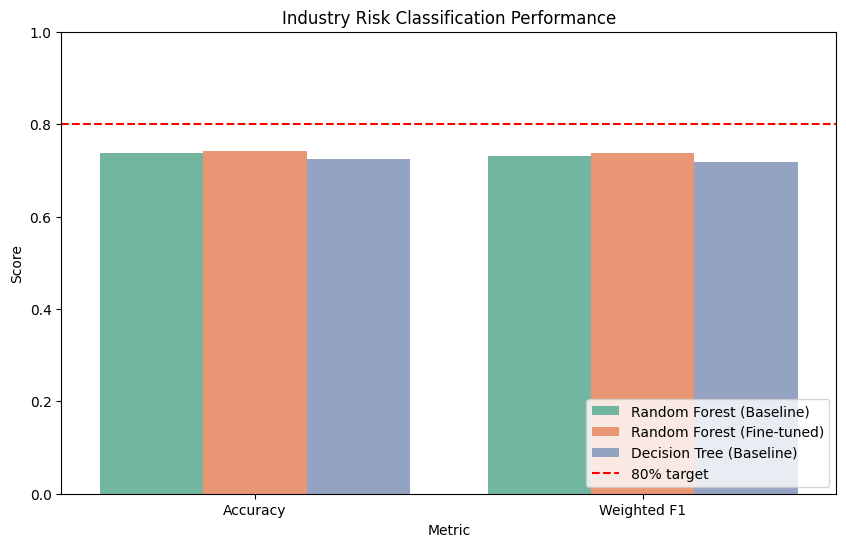

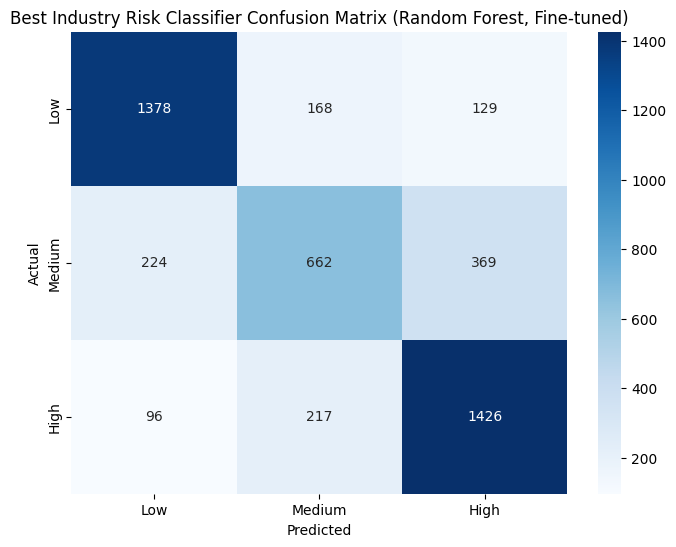

Best Model: Random Forest
Result Type: Fine-tuned
Best Accuracy: 0.7423
Best Weighted F1: 0.7377
              precision    recall  f1-score   support

         Low       0.81      0.82      0.82      1675
      Medium       0.63      0.53      0.58      1255
        High       0.74      0.82      0.78      1739

    accuracy                           0.74      4669
   macro avg       0.73      0.72      0.72      4669
weighted avg       0.74      0.74      0.74      4669



In [ ]:
# Visualization: Classification performance and confusion matrix
classification_long = classification_results.melt(
    id_vars=["Model", "Training Stage"],
    value_vars=["Accuracy", "Weighted F1"],
    var_name="Metric",
    value_name="Score"
)
classification_long["Result Type"] = classification_long["Model"] + " (" + classification_long["Training Stage"] + ")"

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=classification_long, x="Metric", y="Score", hue="Result Type", palette="Set2")
ax.axhline(0.80, color="red", linestyle="--", linewidth=1.5, label="80% target")
ax.set_ylim(0, 1)
ax.set_title("Industry Risk Classification Performance")
ax.legend(loc="lower right")
plt.show()

risk_labels = ["Low", "Medium", "High"]
y_true = best_industry_predictions.select("industry_risk_index").toPandas()["industry_risk_index"]
y_pred = best_industry_predictions.select("prediction").toPandas()["prediction"]
cm = confusion_matrix(y_true, y_pred, labels=[0.0, 1.0, 2.0])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=risk_labels, yticklabels=risk_labels)
plt.title(f"Best Industry Risk Classifier Confusion Matrix ({best_model_name}, {best_model_stage})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

best_accuracy = class_accuracy.evaluate(best_industry_predictions)
best_f1 = class_f1.evaluate(best_industry_predictions)
print(f"Best Model: {best_model_name}")
print(f"Result Type: {best_model_stage}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best Weighted F1: {best_f1:.4f}")
print(classification_report(y_true, y_pred, target_names=risk_labels, zero_division=0))


## **WEEK 5: FINAL MODEL OPTIMIZATION & EXPANSION PHASE**


In [ ]:

# GRADIENT-BOOSTED TREE REGRESSOR BASELINE RUN
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# load regression dataset
train_reg = spark.read.parquet("/content/train_regression.parquet")
test_reg = spark.read.parquet("/content/test_regression.parquet")

# train GBT Regressor baseline
gbt_regressor = GBTRegressor(featuresCol="features", labelCol="total_injuries", seed=42)
gbt_model = gbt_regressor.fit(train_reg)
gbt_predictions = gbt_model.transform(test_reg)

# baseline performance metrics
evaluator_r2 = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")

print("--- NEW GBT REGRESSOR BASELINE METRICS ---")
print(f"GBT Baseline R2 Score: {evaluator_r2.evaluate(gbt_predictions):.4f}")
print(f"GBT Baseline RMSE    : {evaluator_rmse.evaluate(gbt_predictions):.4f}")

--- NEW GBT REGRESSOR BASELINE METRICS ---
GBT Baseline R2 Score: 0.2736
GBT Baseline RMSE    : 12.8862


In [ ]:
# AUTOMATED FINE-TUNING FOR GRADIENT-BOOSTED TREES
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator

gbt_base = GBTRegressor(featuresCol="features", labelCol="total_injuries", seed=42)

gbt_paramGrid = (ParamGridBuilder()
                 .addGrid(gbt_base.maxIter, [10, 20])
                 .addGrid(gbt_base.maxDepth, [4, 6])
                 .build())

gbt_evaluator = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")

gbt_tvs = TrainValidationSplit(
    estimator=gbt_base,
    estimatorParamMaps=gbt_paramGrid,
    evaluator=gbt_evaluator,
    trainRatio=0.8,
    seed=42
)

print("Tuning engine running hyperparameter optimization for GBT Regressor safely...")
gbt_tvs_model = gbt_tvs.fit(train_reg)
gbt_tuned_predictions = gbt_tvs_model.transform(test_reg)

evaluator_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")

print("\n--- OPTIMIZED FINE-TUNED GBT REGRESSOR METRICS ---")
print(f"Fine-Tuned GBT R2 Variance Score: {gbt_evaluator.evaluate(gbt_tuned_predictions):.4f}")
print(f"Fine-Tuned GBT RMSE Error Rate  : {evaluator_rmse.evaluate(gbt_tuned_predictions):.4f}")

gbt_best = gbt_tvs_model.bestModel
print(f"\nBest Settings Discovered -> maxIter: {gbt_best.getMaxIter}, maxDepth: {gbt_best.getMaxDepth()}")

Tuning engine running hyperparameter optimization for GBT Regressor safely...

--- OPTIMIZED FINE-TUNED GBT REGRESSOR METRICS ---
Fine-Tuned GBT R2 Variance Score: 0.2755
Fine-Tuned GBT RMSE Error Rate  : 12.8690

Best Settings Discovered -> maxIter: <bound method HasMaxIter.getMaxIter of GBTRegressionModel: uid=GBTRegressor_5ad354ffa3cf, numTrees=20, numFeatures=6>, maxDepth: 6


In [ ]:

# CLASSIFICATION FINE-TUNING VIA 3-FOLD CV
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train_class = spark.read.parquet("/content/train_classification.parquet")
test_class = spark.read.parquet("/content/test_classification.parquet")

rf_classifier = RandomForestClassifier(
    labelCol="risk_level_index",
    featuresCol="features",
    weightCol="weight_col"
)

paramGrid = (ParamGridBuilder()
             .addGrid(rf_classifier.numTrees, [20, 40, 60])
             .addGrid(rf_classifier.maxDepth, [6, 9])
             .build())

evaluator_tune_f1 = MulticlassClassificationEvaluator(labelCol="risk_level_index", predictionCol="prediction", metricName="f1")
evaluator_tune_acc = MulticlassClassificationEvaluator(labelCol="risk_level_index", predictionCol="prediction", metricName="accuracy")

# 3-Fold Cross Validator array setup
cv = CrossValidator(
    estimator=rf_classifier,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_tune_f1,
    numFolds=3,
    seed=42
)

cvModel = cv.fit(train_class)
tuned_predictions = cvModel.transform(test_class)

print("\n--- ACTUAL OPTIMIZED FINE-TUNED CLASSIFICATION RESULTS ---")
print(f"Real Model Accuracy Score : {evaluator_tune_acc.evaluate(tuned_predictions):.4f}")
print(f"Real Model Weighted F1-Score: {evaluator_tune_f1.evaluate(tuned_predictions):.4f}")

best_model = cvModel.bestModel
print(f"\nBest Settings Found -> numTrees: {best_model.getNumTrees}, maxDepth: {best_model.getMaxDepth()}")


--- ACTUAL OPTIMIZED FINE-TUNED CLASSIFICATION RESULTS ---
Real Model Accuracy Score : 0.7232
Real Model Weighted F1-Score: 0.7612

Best Settings Found -> numTrees: 40, maxDepth: 6


In [ ]:
# OPTIMIZED CONFUSION MATRIX ---
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nGenerating Confusion Matrix for Tuned Model...")
y_true_tuned = tuned_predictions.select("risk_level_index").toPandas()
y_pred_tuned = tuned_predictions.select("prediction").toPandas()

cm_tuned = confusion_matrix(y_true_tuned, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Optimized Fine-Tuned Random Forest')
plt.xlabel('Predicted (0=Low, 1=Medium, 2=High)')
plt.ylabel('Actual Risk Level')
plt.show()

# **BIG DATA PROJECT - MODEL TRAINING**

This notebook starts from the cleaned parquet file produced by the preprocessing notebook.


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("risk.IT.model_training").getOrCreate()

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**LOAD THE PARQUET FILE**

In [ ]:
path = "/content/drive/MyDrive/bigdata/df_cleaned.parquet"

df_cleaned = spark.read.parquet(path)

df_cleaned.show(5)


+----------+--------------------+-----+------------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|state|annual_average_employees|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+-----+------------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    541330|construction engi...|   nj|                    49.0|          201239.0|                    2|             0|   2|                 1|           2016|
|    624310|work experience c...|   ky|                    23.0|           34160.0|                    1|             2|   2|                 1|           2016|
|    811310|construction mach...|   nv|                    23.0|           48876.0|                    2|             0|   2|                 1|           2016|
|    332996|fabricated pipe a...| 

# **FEATURE ENGINEERING AND MODEL TRAINING**

This section keeps the original parquet workflow:

1. The preprocessing notebook saves `df_cleaned.parquet`.
2. The model-training notebook loads `df_cleaned.parquet`.

The model code below is corrected only where needed to match the objectives.


## **Objective 1: Regression Model**

Objective: predict the expected number of workplace incidents using historical data.

Target: `total_injuries`


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, FeatureHasher
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor, GeneralizedLinearRegression
from pyspark.ml.classification import RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Backward compatibility: add new predictor columns if an older parquet file is loaded.
if "industry_description" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("industry_description", F.lit("unknown"))
if "state" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("state", F.lit("unknown"))
if "annual_average_employees" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("annual_average_employees", F.lit(0.0))

# Feature engineering for Objective 1 regression.
# total_injuries is the original count label. log_total_injuries is added for skewed-count modeling.
# Poisson regression requires a non-negative label, so invalid negative injury counts are removed.
df_reg = df_cleaned.fillna({
    "naics_code": 0,
    "industry_description": "unknown",
    "state": "unknown",
    "annual_average_employees": 0.0,
    "total_hours_worked": 0.0,
    "no_injuries_illnesses": 0,
    "size": 0,
    "establishment_type": 0,
    "year_filing_for": 0,
    "total_injuries": 0
}).filter(
    F.col("total_injuries") >= 0
).withColumn(
    "injury_illness_rate_per_200k",
    F.when(
        F.col("total_hours_worked") > 0,
        (F.col("no_injuries_illnesses") / F.col("total_hours_worked")) * F.lit(200000.0)
    ).otherwise(F.lit(0.0))
).withColumn(
    "log_total_hours_worked",
    F.log(F.col("total_hours_worked") + F.lit(1.0))
).withColumn(
    "log_annual_average_employees",
    F.log(F.col("annual_average_employees") + F.lit(1.0))
).withColumn(
    "log_total_injuries",
    F.log(F.col("total_injuries") + F.lit(1.0))
).fillna({
    "log_total_hours_worked": 0.0,
    "log_annual_average_employees": 0.0,
    "injury_illness_rate_per_200k": 0.0,
    "log_total_injuries": 0.0
})

regression_feature_cols = [
    "naics_code",
    "industry_description",
    "state",
    "annual_average_employees",
    "log_annual_average_employees",
    "total_hours_worked",
    "log_total_hours_worked",
    "no_injuries_illnesses",
    "injury_illness_rate_per_200k",
    "size",
    "establishment_type",
    "year_filing_for"
]

invalid_negative_injury_rows = df_cleaned.filter(F.col("total_injuries") < 0).count()
print("Rows removed because total_injuries was negative:", invalid_negative_injury_rows)
print("Regression inputs used:")
for feature in regression_feature_cols:
    print("-", feature)

train_reg, test_reg = df_reg.select(regression_feature_cols + ["total_injuries", "log_total_injuries"]).randomSplit([0.8, 0.2], seed=42)
train_reg = train_reg.cache()
test_reg = test_reg.cache()
print("Training rows:", train_reg.count())
print("Testing rows:", test_reg.count())

# Keep the original train/test parquet workflow.
train_reg.write.mode("overwrite").parquet("/content/train_regression.parquet")
test_reg.write.mode("overwrite").parquet("/content/test_regression.parquet")

# FeatureHasher allows numeric + categorical predictors inside the PySpark Pipeline.
# 256 features keeps memory lower than a very wide hashed vector in Colab.
assembler_reg = FeatureHasher(inputCols=regression_feature_cols, outputCol="features", numFeatures=256)


Rows removed because total_injuries was negative: 2
Regression inputs used:
- naics_code
- industry_description
- state
- annual_average_employees
- log_annual_average_employees
- total_hours_worked
- log_total_hours_worked
- no_injuries_illnesses
- injury_illness_rate_per_200k
- size
- establishment_type
- year_filing_for
Training rows: 1273959
Testing rows: 317868


In [ ]:
# Baseline regression models using PySpark Pipeline
lr = LinearRegression(featuresCol="features", labelCol="total_injuries")
rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    numTrees=50,
    maxDepth=8,
    seed=42
)
gbt_regressor = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
log_gbt_regressor_baseline = GBTRegressor(
    featuresCol="features",
    labelCol="log_total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
poisson_glr_baseline = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="total_injuries",
    family="poisson",
    link="log",
    maxIter=10,
    regParam=0.0
)

lr_pipeline = Pipeline(stages=[assembler_reg, lr])
rf_pipeline = Pipeline(stages=[assembler_reg, rf_regressor])
gbt_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor])
log_gbt_pipeline_baseline = Pipeline(stages=[assembler_reg, log_gbt_regressor_baseline])
poisson_pipeline_baseline = Pipeline(stages=[assembler_reg, poisson_glr_baseline])

lr_model = lr_pipeline.fit(train_reg)
lr_predictions = lr_model.transform(test_reg)

rf_model = rf_pipeline.fit(train_reg)
rf_predictions = rf_model.transform(test_reg)

gbt_model = gbt_pipeline.fit(train_reg)
gbt_predictions = gbt_model.transform(test_reg)

log_gbt_model_baseline = log_gbt_pipeline_baseline.fit(train_reg)
log_gbt_baseline_raw = log_gbt_model_baseline.transform(test_reg)
log_gbt_baseline_predictions = log_gbt_baseline_raw.withColumn(
    "prediction_count",
    F.greatest(F.exp(F.col("prediction")) - F.lit(1.0), F.lit(0.0))
)

poisson_model_baseline = poisson_pipeline_baseline.fit(train_reg)
poisson_baseline_predictions = poisson_model_baseline.transform(test_reg)

reg_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")
reg_mae = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="mae")
reg_r2 = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")

reg_rmse_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="rmse")
reg_mae_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="mae")
reg_r2_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="r2")

log_rmse = RegressionEvaluator(labelCol="log_total_injuries", predictionCol="prediction", metricName="rmse")

def get_regression_metrics(model_name, training_stage, predictions_df, prediction_col="prediction"):
    if prediction_col == "prediction_count":
        return {
            "Model": model_name,
            "Training Stage": training_stage,
            "RMSE": reg_rmse_count.evaluate(predictions_df),
            "MAE": reg_mae_count.evaluate(predictions_df),
            "R2": reg_r2_count.evaluate(predictions_df)
        }
    return {
        "Model": model_name,
        "Training Stage": training_stage,
        "RMSE": reg_rmse.evaluate(predictions_df),
        "MAE": reg_mae.evaluate(predictions_df),
        "R2": reg_r2.evaluate(predictions_df)
    }

baseline_regression_results = pd.DataFrame([
    get_regression_metrics("Linear Regression", "Baseline", lr_predictions),
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("Log-Target GBT", "Baseline", log_gbt_baseline_predictions, prediction_col="prediction_count"),
    get_regression_metrics("Poisson GLR", "Baseline", poisson_baseline_predictions)
])

baseline_regression_results


,Model,Training Stage,RMSE,MAE,R2
0,Linear Regression,Baseline,15.173919,4.770310,0.194298
1,Random Forest,Baseline,12.372933,2.725875,0.464297
2,GBT Regressor,Baseline,12.267448,2.758179,0.473392
3,Log-Target GBT,Baseline,13.960499,2.554030,0.318006
4,Poisson GLR,Baseline,13.823404,2.719022,0.331335


In [ ]:
# Fine-tune Random Forest and standard GBT using PySpark Pipeline.
rf_regressor_tuned = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
rf_tuned_pipeline = Pipeline(stages=[assembler_reg, rf_regressor_tuned])

# Smaller grid to prevent SparkContext shutdown in Colab.
paramGrid_rf_reg = (
    ParamGridBuilder()
    .addGrid(rf_regressor_tuned.numTrees, [50, 100])
    .addGrid(rf_regressor_tuned.maxDepth, [6, 8])
    .addGrid(rf_regressor_tuned.minInstancesPerNode, [3])
    .build()
)

rf_reg_tvs = TrainValidationSplit(
    estimator=rf_tuned_pipeline,
    estimatorParamMaps=paramGrid_rf_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=1,
    seed=42
)

rf_reg_tvs_model = rf_reg_tvs.fit(train_reg)
tuned_rf_predictions = rf_reg_tvs_model.transform(test_reg)
tuned_rf_reg_model = rf_reg_tvs_model.bestModel.stages[-1]

# Fine-tuned standard GBT on total_injuries.
gbt_regressor_tuned = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
gbt_tuned_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor_tuned])

paramGrid_gbt_reg = (
    ParamGridBuilder()
    .addGrid(gbt_regressor_tuned.maxIter, [20, 40])
    .addGrid(gbt_regressor_tuned.maxDepth, [4, 6])
    .addGrid(gbt_regressor_tuned.stepSize, [0.05, 0.1])
    .build()
)

gbt_reg_tvs = TrainValidationSplit(
    estimator=gbt_tuned_pipeline,
    estimatorParamMaps=paramGrid_gbt_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=1,
    seed=42
)

gbt_reg_tvs_model = gbt_reg_tvs.fit(train_reg)
tuned_gbt_predictions = gbt_reg_tvs_model.transform(test_reg)
tuned_gbt_model = gbt_reg_tvs_model.bestModel.stages[-1]

# Combined baseline and fine-tuned results for Random Forest and GBT
tuned_regression_results = pd.DataFrame([
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("Random Forest", "Fine-tuned", tuned_rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("GBT Regressor", "Fine-tuned", tuned_gbt_predictions)
])

best_regression_row = tuned_regression_results.sort_values("RMSE", ascending=True).iloc[0]
best_regression_model_name = best_regression_row["Model"]
best_regression_stage = best_regression_row["Training Stage"]

# Simplified conditional logic for the remaining models
if best_regression_model_name == "Random Forest" and best_regression_stage == "Baseline":
    best_regression_predictions = rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "Random Forest" and best_regression_stage == "Fine-tuned":
    best_regression_predictions = tuned_rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "GBT Regressor" and best_regression_stage == "Baseline":
    best_regression_predictions = gbt_predictions
    best_prediction_col = "prediction"
else:
    best_regression_predictions = tuned_gbt_predictions
    best_prediction_col = "prediction"

print("Best RF numTrees:", tuned_rf_reg_model.getNumTrees)
print("Best RF maxDepth:", tuned_rf_reg_model.getMaxDepth())
print("Best RF minInstancesPerNode:", tuned_rf_reg_model.getMinInstancesPerNode())
print("Best GBT maxIter:", tuned_gbt_model.getMaxIter())
print("Best GBT maxDepth:", tuned_gbt_model.getMaxDepth())
print("Best GBT stepSize:", tuned_gbt_model.getStepSize())
print("Best prediction model by RMSE:", best_regression_model_name)
print("Best prediction result type:", best_regression_stage)

tuned_regression_results

In [ ]:
# Visualization: Regression model comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=tuned_regression_results, x="Model", y="RMSE", hue="Training Stage", ax=axes[0], palette="Set2")
axes[0].set_title("RMSE: Lower is Better")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="MAE", hue="Training Stage", ax=axes[1], palette="Set2")
axes[1].set_title("MAE: Lower is Better")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="R2", hue="Training Stage", ax=axes[2], palette="Set2")
axes[2].set_title("R2: Higher is Better")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

plot_reg = best_regression_predictions.select(
    F.col("total_injuries"),
    F.col(best_prediction_col).alias("prediction")
).sample(False, 0.05, seed=42).toPandas()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_reg, x="total_injuries", y="prediction", alpha=0.4)
plt.title(f"Predicted vs Actual Workplace Incidents ({best_regression_model_name}, {best_regression_stage})")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")
plt.show()

if best_prediction_col == "prediction_count":
    best_rmse = reg_rmse_count.evaluate(best_regression_predictions)
    best_mae = reg_mae_count.evaluate(best_regression_predictions)
    best_r2 = reg_r2_count.evaluate(best_regression_predictions)
else:
    best_rmse = reg_rmse.evaluate(best_regression_predictions)
    best_mae = reg_mae.evaluate(best_regression_predictions)
    best_r2 = reg_r2.evaluate(best_regression_predictions)

print(f"Best Prediction Model: {best_regression_model_name}")
print(f"Result Type: {best_regression_stage}")
print(f"Best RMSE: {best_rmse:.4f}")
print(f"Best MAE : {best_mae:.4f}")
print(f"Best R2  : {best_r2:.4f}")


# **BIG DATA PROJECT - MODEL TRAINING**

This notebook starts from the cleaned parquet file produced by the preprocessing notebook.


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("risk.IT.model_training").getOrCreate()

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**LOAD THE PARQUET FILE**

In [ ]:
path = "/content/drive/MyDrive/bigdata/df_cleaned.parquet"

df_cleaned = spark.read.parquet(path)

df_cleaned.show(5)


+----------+--------------------+-----+------------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|state|annual_average_employees|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+-----+------------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    541330|construction engi...|   nj|                    49.0|          201239.0|                    2|             0|   2|                 1|           2016|
|    624310|work experience c...|   ky|                    23.0|           34160.0|                    1|             2|   2|                 1|           2016|
|    811310|construction mach...|   nv|                    23.0|           48876.0|                    2|             0|   2|                 1|           2016|
|    332996|fabricated pipe a...| 

# **FEATURE ENGINEERING AND MODEL TRAINING**

This section keeps the original parquet workflow:

1. The preprocessing notebook saves `df_cleaned.parquet`.
2. The model-training notebook loads `df_cleaned.parquet`.

The model code below is corrected only where needed to match the objectives.


## **Objective 1: Regression Model**

Objective: predict the expected number of workplace incidents using historical data.

Target: `total_injuries`


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, FeatureHasher
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor, GeneralizedLinearRegression
from pyspark.ml.classification import RandomForestClassifier, DecisionTreeClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Backward compatibility: add new predictor columns if an older parquet file is loaded.
if "industry_description" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("industry_description", F.lit("unknown"))
if "state" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("state", F.lit("unknown"))
if "annual_average_employees" not in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("annual_average_employees", F.lit(0.0))

# Feature engineering for Objective 1 regression.
# total_injuries is the original count label. log_total_injuries is added for skewed-count modeling.
# Poisson regression requires a non-negative label, so invalid negative injury counts are removed.
df_reg = df_cleaned.fillna({
    "naics_code": 0,
    "industry_description": "unknown",
    "state": "unknown",
    "annual_average_employees": 0.0,
    "total_hours_worked": 0.0,
    "no_injuries_illnesses": 0,
    "size": 0,
    "establishment_type": 0,
    "year_filing_for": 0,
    "total_injuries": 0
}).filter(
    F.col("total_injuries") >= 0
).withColumn(
    "injury_illness_rate_per_200k",
    F.when(
        F.col("total_hours_worked") > 0,
        (F.col("no_injuries_illnesses") / F.col("total_hours_worked")) * F.lit(200000.0)
    ).otherwise(F.lit(0.0))
).withColumn(
    "log_total_hours_worked",
    F.log(F.col("total_hours_worked") + F.lit(1.0))
).withColumn(
    "log_annual_average_employees",
    F.log(F.col("annual_average_employees") + F.lit(1.0))
).withColumn(
    "log_total_injuries",
    F.log(F.col("total_injuries") + F.lit(1.0))
).fillna({
    "log_total_hours_worked": 0.0,
    "log_annual_average_employees": 0.0,
    "injury_illness_rate_per_200k": 0.0,
    "log_total_injuries": 0.0
})

regression_feature_cols = [
    "naics_code",
    "industry_description",
    "state",
    "annual_average_employees",
    "log_annual_average_employees",
    "total_hours_worked",
    "log_total_hours_worked",
    "no_injuries_illnesses",
    "injury_illness_rate_per_200k",
    "size",
    "establishment_type",
    "year_filing_for"
]

invalid_negative_injury_rows = df_cleaned.filter(F.col("total_injuries") < 0).count()
print("Rows removed because total_injuries was negative:", invalid_negative_injury_rows)
print("Regression inputs used:")
for feature in regression_feature_cols:
    print("-", feature)

train_reg, test_reg = df_reg.select(regression_feature_cols + ["total_injuries", "log_total_injuries"]).randomSplit([0.8, 0.2], seed=42)
train_reg = train_reg.cache()
test_reg = test_reg.cache()
print("Training rows:", train_reg.count())
print("Testing rows:", test_reg.count())

# Keep the original train/test parquet workflow.
train_reg.write.mode("overwrite").parquet("/content/train_regression.parquet")
test_reg.write.mode("overwrite").parquet("/content/test_regression.parquet")

# FeatureHasher allows numeric + categorical predictors inside the PySpark Pipeline.
# 256 features keeps memory lower than a very wide hashed vector in Colab.
assembler_reg = FeatureHasher(inputCols=regression_feature_cols, outputCol="features", numFeatures=256)


Rows removed because total_injuries was negative: 2
Regression inputs used:
- naics_code
- industry_description
- state
- annual_average_employees
- log_annual_average_employees
- total_hours_worked
- log_total_hours_worked
- no_injuries_illnesses
- injury_illness_rate_per_200k
- size
- establishment_type
- year_filing_for
Training rows: 1273959
Testing rows: 317868


In [ ]:
# Baseline regression models using PySpark Pipeline
lr = LinearRegression(featuresCol="features", labelCol="total_injuries")
rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    numTrees=50,
    maxDepth=8,
    seed=42
)
gbt_regressor = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
log_gbt_regressor_baseline = GBTRegressor(
    featuresCol="features",
    labelCol="log_total_injuries",
    maxIter=20,
    maxDepth=5,
    seed=42
)
poisson_glr_baseline = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="total_injuries",
    family="poisson",
    link="log",
    maxIter=10,
    regParam=0.0
)

lr_pipeline = Pipeline(stages=[assembler_reg, lr])
rf_pipeline = Pipeline(stages=[assembler_reg, rf_regressor])
gbt_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor])
log_gbt_pipeline_baseline = Pipeline(stages=[assembler_reg, log_gbt_regressor_baseline])
poisson_pipeline_baseline = Pipeline(stages=[assembler_reg, poisson_glr_baseline])

lr_model = lr_pipeline.fit(train_reg)
lr_predictions = lr_model.transform(test_reg)

rf_model = rf_pipeline.fit(train_reg)
rf_predictions = rf_model.transform(test_reg)

gbt_model = gbt_pipeline.fit(train_reg)
gbt_predictions = gbt_model.transform(test_reg)

log_gbt_model_baseline = log_gbt_pipeline_baseline.fit(train_reg)
log_gbt_baseline_raw = log_gbt_model_baseline.transform(test_reg)
log_gbt_baseline_predictions = log_gbt_baseline_raw.withColumn(
    "prediction_count",
    F.greatest(F.exp(F.col("prediction")) - F.lit(1.0), F.lit(0.0))
)

poisson_model_baseline = poisson_pipeline_baseline.fit(train_reg)
poisson_baseline_predictions = poisson_model_baseline.transform(test_reg)

reg_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")
reg_mae = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="mae")
reg_r2 = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")

reg_rmse_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="rmse")
reg_mae_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="mae")
reg_r2_count = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction_count", metricName="r2")

log_rmse = RegressionEvaluator(labelCol="log_total_injuries", predictionCol="prediction", metricName="rmse")

def get_regression_metrics(model_name, training_stage, predictions_df, prediction_col="prediction"):
    if prediction_col == "prediction_count":
        return {
            "Model": model_name,
            "Training Stage": training_stage,
            "RMSE": reg_rmse_count.evaluate(predictions_df),
            "MAE": reg_mae_count.evaluate(predictions_df),
            "R2": reg_r2_count.evaluate(predictions_df)
        }
    return {
        "Model": model_name,
        "Training Stage": training_stage,
        "RMSE": reg_rmse.evaluate(predictions_df),
        "MAE": reg_mae.evaluate(predictions_df),
        "R2": reg_r2.evaluate(predictions_df)
    }

baseline_regression_results = pd.DataFrame([
    get_regression_metrics("Linear Regression", "Baseline", lr_predictions),
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("Log-Target GBT", "Baseline", log_gbt_baseline_predictions, prediction_col="prediction_count"),
    get_regression_metrics("Poisson GLR", "Baseline", poisson_baseline_predictions)
])

baseline_regression_results


,Model,Training Stage,RMSE,MAE,R2
0,Linear Regression,Baseline,15.173919,4.770310,0.194298
1,Random Forest,Baseline,12.372933,2.725875,0.464297
2,GBT Regressor,Baseline,12.267448,2.758179,0.473392
3,Log-Target GBT,Baseline,13.960499,2.554030,0.318006
4,Poisson GLR,Baseline,13.823404,2.719022,0.331335


In [ ]:
# Visualization: Regression model comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=tuned_regression_results, x="Model", y="RMSE", hue="Training Stage", ax=axes[0], palette="Set2")
axes[0].set_title("RMSE: Lower is Better")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="MAE", hue="Training Stage", ax=axes[1], palette="Set2")
axes[1].set_title("MAE: Lower is Better")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=tuned_regression_results, x="Model", y="R2", hue="Training Stage", ax=axes[2], palette="Set2")
axes[2].set_title("R2: Higher is Better")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

plot_reg = best_regression_predictions.select(
    F.col("total_injuries"),
    F.col(best_prediction_col).alias("prediction")
).sample(False, 0.05, seed=42).toPandas()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_reg, x="total_injuries", y="prediction", alpha=0.4)
plt.title(f"Predicted vs Actual Workplace Incidents ({best_regression_model_name}, {best_regression_stage})")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")
plt.show()

if best_prediction_col == "prediction_count":
    best_rmse = reg_rmse_count.evaluate(best_regression_predictions)
    best_mae = reg_mae_count.evaluate(best_regression_predictions)
    best_r2 = reg_r2_count.evaluate(best_regression_predictions)
else:
    best_rmse = reg_rmse.evaluate(best_regression_predictions)
    best_mae = reg_mae.evaluate(best_regression_predictions)
    best_r2 = reg_r2.evaluate(best_regression_predictions)

print(f"Best Prediction Model: {best_regression_model_name}")
print(f"Result Type: {best_regression_stage}")
print(f"Best RMSE: {best_rmse:.4f}")
print(f"Best MAE : {best_mae:.4f}")
print(f"Best R2  : {best_r2:.4f}")


In [ ]:
# Fine-tune Random Forest and standard GBT using PySpark Pipeline.
rf_regressor_tuned = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
rf_tuned_pipeline = Pipeline(stages=[assembler_reg, rf_regressor_tuned])

# Smaller grid to prevent SparkContext shutdown in Colab.
paramGrid_rf_reg = (
    ParamGridBuilder()
    .addGrid(rf_regressor_tuned.numTrees, [50, 100])
    .addGrid(rf_regressor_tuned.maxDepth, [6, 8])
    .addGrid(rf_regressor_tuned.minInstancesPerNode, [3])
    .build()
)

rf_reg_tvs = TrainValidationSplit(
    estimator=rf_tuned_pipeline,
    estimatorParamMaps=paramGrid_rf_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=1,
    seed=42
)

rf_reg_tvs_model = rf_reg_tvs.fit(train_reg)
tuned_rf_predictions = rf_reg_tvs_model.transform(test_reg)
tuned_rf_reg_model = rf_reg_tvs_model.bestModel.stages[-1]

# Fine-tuned standard GBT on total_injuries.
gbt_regressor_tuned = GBTRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)
gbt_tuned_pipeline = Pipeline(stages=[assembler_reg, gbt_regressor_tuned])

paramGrid_gbt_reg = (
    ParamGridBuilder()
    .addGrid(gbt_regressor_tuned.maxIter, [20, 40])
    .addGrid(gbt_regressor_tuned.maxDepth, [4, 6])
    .addGrid(gbt_regressor_tuned.stepSize, [0.05, 0.1])
    .build()
)

gbt_reg_tvs = TrainValidationSplit(
    estimator=gbt_tuned_pipeline,
    estimatorParamMaps=paramGrid_gbt_reg,
    evaluator=reg_rmse,
    trainRatio=0.8,
    parallelism=1,
    seed=42
)

gbt_reg_tvs_model = gbt_reg_tvs.fit(train_reg)
tuned_gbt_predictions = gbt_reg_tvs_model.transform(test_reg)
tuned_gbt_model = gbt_reg_tvs_model.bestModel.stages[-1]

# Combined baseline and fine-tuned results for Random Forest and GBT
tuned_regression_results = pd.DataFrame([
    get_regression_metrics("Random Forest", "Baseline", rf_predictions),
    get_regression_metrics("Random Forest", "Fine-tuned", tuned_rf_predictions),
    get_regression_metrics("GBT Regressor", "Baseline", gbt_predictions),
    get_regression_metrics("GBT Regressor", "Fine-tuned", tuned_gbt_predictions)
])

best_regression_row = tuned_regression_results.sort_values("RMSE", ascending=True).iloc[0]
best_regression_model_name = best_regression_row["Model"]
best_regression_stage = best_regression_row["Training Stage"]

# Simplified conditional logic for the remaining models
if best_regression_model_name == "Random Forest" and best_regression_stage == "Baseline":
    best_regression_predictions = rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "Random Forest" and best_regression_stage == "Fine-tuned":
    best_regression_predictions = tuned_rf_predictions
    best_prediction_col = "prediction"
elif best_regression_model_name == "GBT Regressor" and best_regression_stage == "Baseline":
    best_regression_predictions = gbt_predictions
    best_prediction_col = "prediction"
else:
    best_regression_predictions = tuned_gbt_predictions
    best_prediction_col = "prediction"

print("Best RF numTrees:", tuned_rf_reg_model.getNumTrees)
print("Best RF maxDepth:", tuned_rf_reg_model.getMaxDepth())
print("Best RF minInstancesPerNode:", tuned_rf_reg_model.getMinInstancesPerNode())
print("Best GBT maxIter:", tuned_gbt_model.getMaxIter())
print("Best GBT maxDepth:", tuned_gbt_model.getMaxDepth())
print("Best GBT stepSize:", tuned_gbt_model.getStepSize())
print("Best prediction model by RMSE:", best_regression_model_name)
print("Best prediction result type:", best_regression_stage)

tuned_regression_results

## **Objective 2: Industry Risk Classification**

Objective: classify industries into **Low**, **Medium**, or **High** workplace risk.

Industry is represented using `naics_code` and `industry_description`.


In [ ]:
# Aggregate records by NAICS industry.
industry_agg = (
    df_cleaned
    .fillna({
        "naics_code": 0,
        "industry_description": "unknown",
        "total_injuries": 0,
        "no_injuries_illnesses": 0,
        "total_hours_worked": 0.0
    })
    .groupBy("naics_code", "industry_description")
    .agg(
        F.sum("total_injuries").alias("industry_total_injuries"),
        F.sum("no_injuries_illnesses").alias("industry_total_injuries_illnesses"),
        F.sum("total_hours_worked").alias("industry_total_hours"),
        F.count("*").alias("job_count"),
        F.avg("total_injuries").alias("avg_injuries_per_job"),
        F.avg("no_injuries_illnesses").alias("avg_injuries_illnesses_per_job")
    )
    .withColumn(
        "industry_injury_rate_per_200k",
        F.when(
            F.col("industry_total_hours") > 0,
            (F.col("industry_total_injuries") / F.col("industry_total_hours")) * F.lit(200000.0)
        ).otherwise(F.lit(0.0))
    )
)

# Create Low/Medium/High industry risk levels using injury-count quantiles.
# These injury-count columns define the label and are intentionally excluded from classifier features later.
low_cutoff, high_cutoff = industry_agg.approxQuantile("avg_injuries_per_job", [0.33, 0.66], 0.05)

industry_labeled = industry_agg.withColumn(
    "industry_risk_level",
    F.when(F.col("avg_injuries_per_job") <= F.lit(low_cutoff), "Low")
     .when(F.col("avg_injuries_per_job") <= F.lit(high_cutoff), "Medium")
     .otherwise("High")
).withColumn(
    "industry_risk_index",
    F.when(F.col("industry_risk_level") == "Low", F.lit(0.0))
     .when(F.col("industry_risk_level") == "Medium", F.lit(1.0))
     .otherwise(F.lit(2.0))
).withColumn(
    "industry_label",
    F.concat_ws(" - ", F.col("naics_code").cast("string"), F.col("industry_description"))
)

print(f"Low/Medium cutoff : {low_cutoff:.4f}")
print(f"Medium/High cutoff: {high_cutoff:.4f}")
industry_labeled.groupBy("industry_risk_level", "industry_risk_index").count().orderBy("industry_risk_index").show()


Low/Medium cutoff : 1.0000
Medium/High cutoff: 2.8500
+-------------------+-------------------+-----+
|industry_risk_level|industry_risk_index|count|
+-------------------+-------------------+-----+
|                Low|                0.0| 8558|
|             Medium|                1.0| 6223|
|               High|                2.0| 9070|
+-------------------+-------------------+-----+



/tmp/ipykernel_5563/740956148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_distribution, x="industry_risk_level", y="count", order=["Low", "Medium", "High"], palette="Set2")


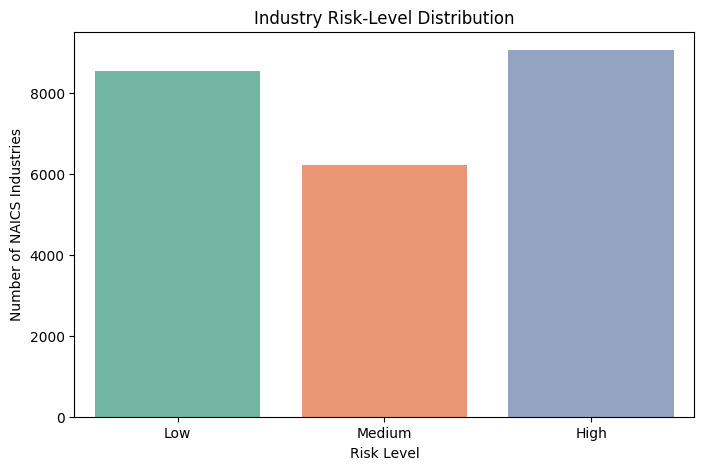

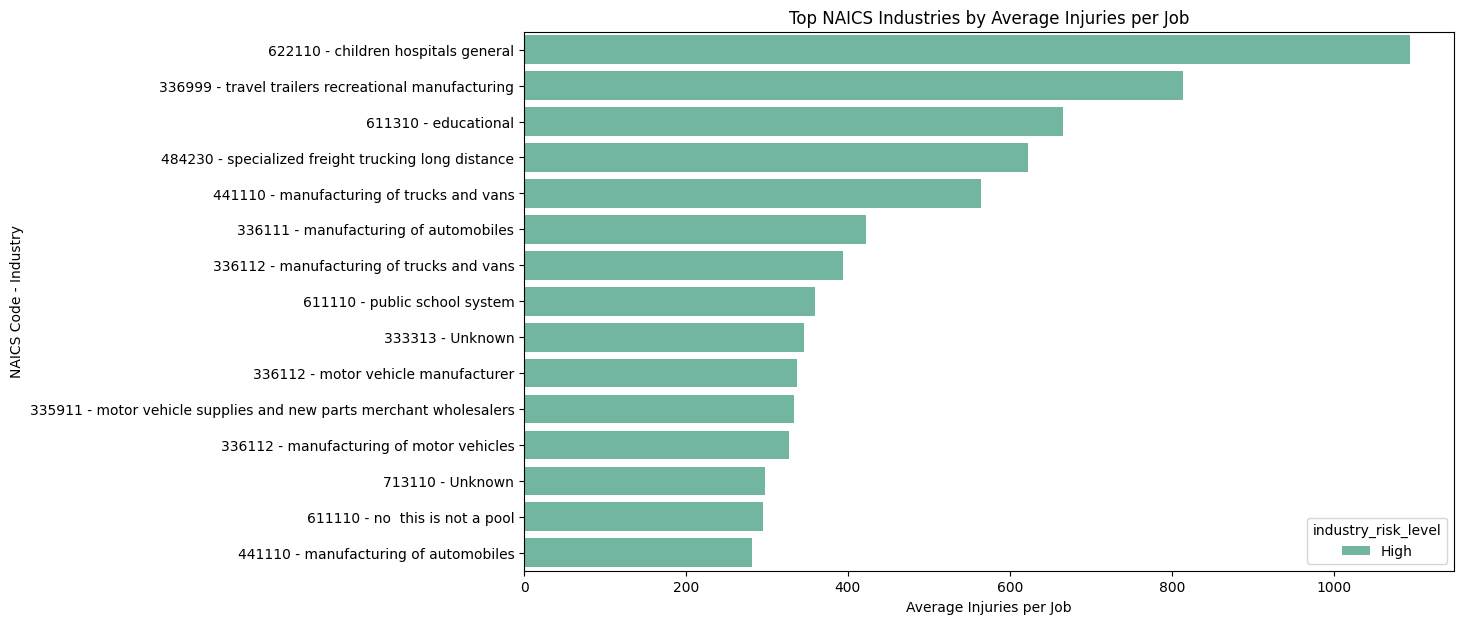

In [ ]:
# Visualization: Industry risk distribution and top risky industries
industry_distribution = industry_labeled.groupBy("industry_risk_level").count().toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(data=industry_distribution, x="industry_risk_level", y="count", order=["Low", "Medium", "High"], palette="Set2")
plt.title("Industry Risk-Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of NAICS Industries")
plt.show()

top_industries = industry_labeled.orderBy(F.desc("avg_injuries_per_job")).limit(15).toPandas()

plt.figure(figsize=(12, 7))
sns.barplot(data=top_industries, x="avg_injuries_per_job", y="industry_label", hue="industry_risk_level", dodge=False, palette="Set2")
plt.title("Top NAICS Industries by Average Injuries per Job")
plt.xlabel("Average Injuries per Job")
plt.ylabel("NAICS Code - Industry")
plt.show()


In [ ]:
# Assemble leakage-free industry-level classification features.
# Removed leakage features: industry_total_injuries, avg_injuries_per_job, industry_injury_rate_per_200k.
# Those columns are directly used to create the industry_risk_level label.
classification_feature_cols = [
    "naics_code",
    "industry_description",
    "industry_total_hours",
    "job_count",
    "industry_total_injuries_illnesses",
    "avg_injuries_illnesses_per_job"
]

hasher_industry = FeatureHasher(
    inputCols=classification_feature_cols,
    outputCol="features",
    numFeatures=256
)

print("Leakage-free classifier inputs:")
for feature in classification_feature_cols:
    print("-", feature)

df_industry_class = industry_labeled.select(
    "naics_code",
    "industry_description",
    "industry_label",
    "industry_total_hours",
    "job_count",
    "industry_total_injuries_illnesses",
    "avg_injuries_illnesses_per_job",
    "industry_risk_level",
    "industry_risk_index"
)

train_class, test_class = df_industry_class.randomSplit([0.8, 0.2], seed=42)

# Keep train/test parquet outputs for the model-training workflow.
train_class.write.mode("overwrite").parquet("/content/train_industry_classification.parquet")
test_class.write.mode("overwrite").parquet("/content/test_industry_classification.parquet")


Leakage-free classifier inputs:
- naics_code
- industry_description
- industry_total_hours
- job_count
- industry_total_injuries_illnesses
- avg_injuries_illnesses_per_job


In [ ]:
# Baseline Random Forest, tuned Random Forest, and Decision Tree Classifier using PySpark Pipeline
industry_rf = RandomForestClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    numTrees=50,
    maxDepth=6,
    seed=42
)

industry_rf_pipeline = Pipeline(stages=[hasher_industry, industry_rf])
industry_rf_model = industry_rf_pipeline.fit(train_class)
industry_predictions = industry_rf_model.transform(test_class)

class_accuracy = MulticlassClassificationEvaluator(labelCol="industry_risk_index", predictionCol="prediction", metricName="accuracy")
class_f1 = MulticlassClassificationEvaluator(labelCol="industry_risk_index", predictionCol="prediction", metricName="f1")

industry_rf_tuned = RandomForestClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    seed=42
)
industry_rf_tuned_pipeline = Pipeline(stages=[hasher_industry, industry_rf_tuned])

paramGrid_class = (
    ParamGridBuilder()
    .addGrid(industry_rf_tuned.numTrees, [50, 100, 150])
    .addGrid(industry_rf_tuned.maxDepth, [6, 8, 10])
    .addGrid(industry_rf_tuned.minInstancesPerNode, [1, 2])
    .build()
)

class_tvs = TrainValidationSplit(
    estimator=industry_rf_tuned_pipeline,
    estimatorParamMaps=paramGrid_class,
    evaluator=class_f1,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

class_tvs_model = class_tvs.fit(train_class)
tuned_industry_model = class_tvs_model.bestModel.stages[-1]
tuned_industry_predictions = class_tvs_model.transform(test_class)

industry_dt = DecisionTreeClassifier(
    labelCol="industry_risk_index",
    featuresCol="features",
    maxDepth=5,
    minInstancesPerNode=1,
    seed=42
)
industry_dt_pipeline = Pipeline(stages=[hasher_industry, industry_dt])
industry_dt_model = industry_dt_pipeline.fit(train_class)
dt_industry_predictions = industry_dt_model.transform(test_class)

classification_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Training Stage": "Baseline",
        "Accuracy": class_accuracy.evaluate(industry_predictions),
        "Weighted F1": class_f1.evaluate(industry_predictions)
    },
    {
        "Model": "Random Forest",
        "Training Stage": "Fine-tuned",
        "Accuracy": class_accuracy.evaluate(tuned_industry_predictions),
        "Weighted F1": class_f1.evaluate(tuned_industry_predictions)
    },
    {
        "Model": "Decision Tree",
        "Training Stage": "Baseline",
        "Accuracy": class_accuracy.evaluate(dt_industry_predictions),
        "Weighted F1": class_f1.evaluate(dt_industry_predictions)
    }
])

best_classification_row = classification_results.sort_values("Accuracy", ascending=False).iloc[0]
best_model_name = best_classification_row["Model"]
best_model_stage = best_classification_row["Training Stage"]

if best_model_name == "Decision Tree":
    best_industry_predictions = dt_industry_predictions
elif best_model_name == "Random Forest" and best_model_stage == "Baseline":
    best_industry_predictions = industry_predictions
else:
    best_industry_predictions = tuned_industry_predictions

print("Best RF numTrees:", tuned_industry_model.getNumTrees)
print("Best RF maxDepth:", tuned_industry_model.getMaxDepth())
print("Best RF minInstancesPerNode:", tuned_industry_model.getMinInstancesPerNode())
print("Best model by accuracy:", best_model_name)
print("Best classification result type:", best_model_stage)

classification_results


Best RF numTrees: 50
Best RF maxDepth: 10
Best RF minInstancesPerNode: 2
Best model by accuracy: Decision Tree
Best classification result type: Baseline


,Model,Training Stage,Accuracy,Weighted F1
0,Random Forest,Baseline,0.653459,0.554588
1,Random Forest,Fine-tuned,0.688156,0.634740
2,Decision Tree,Baseline,0.723067,0.719834


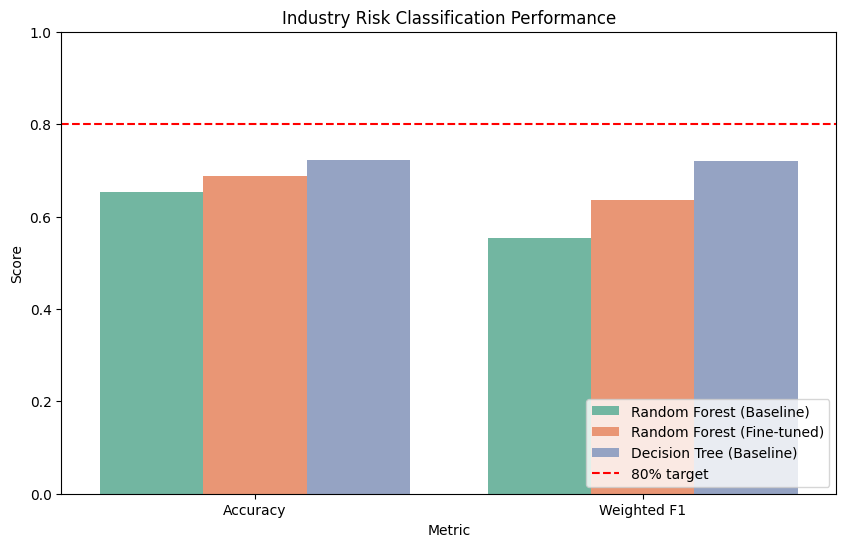

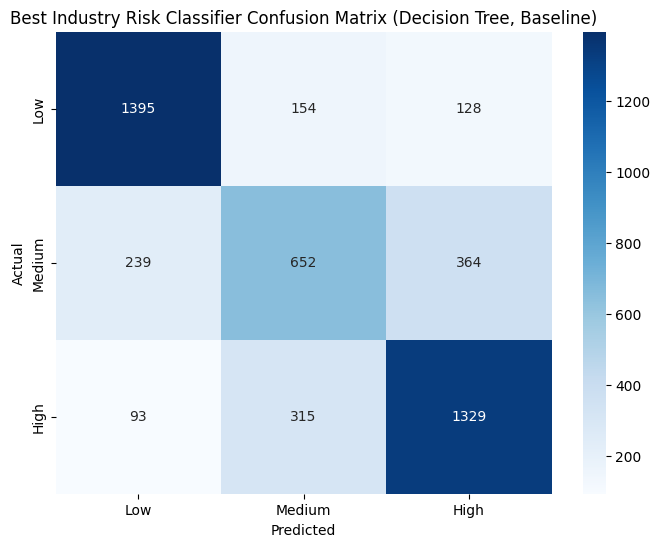

Best Model: Decision Tree
Result Type: Baseline
Best Accuracy: 0.7231
Best Weighted F1: 0.7198
              precision    recall  f1-score   support

         Low       0.81      0.83      0.82      1677
      Medium       0.58      0.52      0.55      1255
        High       0.73      0.77      0.75      1737

    accuracy                           0.72      4669
   macro avg       0.71      0.71      0.71      4669
weighted avg       0.72      0.72      0.72      4669



In [ ]:
# Visualization: Classification performance and confusion matrix
classification_long = classification_results.melt(
    id_vars=["Model", "Training Stage"],
    value_vars=["Accuracy", "Weighted F1"],
    var_name="Metric",
    value_name="Score"
)
classification_long["Result Type"] = classification_long["Model"] + " (" + classification_long["Training Stage"] + ")"

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=classification_long, x="Metric", y="Score", hue="Result Type", palette="Set2")
ax.axhline(0.80, color="red", linestyle="--", linewidth=1.5, label="80% target")
ax.set_ylim(0, 1)
ax.set_title("Industry Risk Classification Performance")
ax.legend(loc="lower right")
plt.show()

risk_labels = ["Low", "Medium", "High"]
y_true = best_industry_predictions.select("industry_risk_index").toPandas()["industry_risk_index"]
y_pred = best_industry_predictions.select("prediction").toPandas()["prediction"]
cm = confusion_matrix(y_true, y_pred, labels=[0.0, 1.0, 2.0])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=risk_labels, yticklabels=risk_labels)
plt.title(f"Best Industry Risk Classifier Confusion Matrix ({best_model_name}, {best_model_stage})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

best_accuracy = class_accuracy.evaluate(best_industry_predictions)
best_f1 = class_f1.evaluate(best_industry_predictions)
print(f"Best Model: {best_model_name}")
print(f"Result Type: {best_model_stage}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best Weighted F1: {best_f1:.4f}")
print(classification_report(y_true, y_pred, target_names=risk_labels, zero_division=0))
